In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


Implement using ResNet 50

In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
train_data = datasets.ImageFolder(root=r"C:\Users\PRATYUSH\OneDrive\Desktop\college\cses\archive\chest_xray\train", transform=transform)
test_data = datasets.ImageFolder(root=r"C:\Users\PRATYUSH\OneDrive\Desktop\college\cses\archive\chest_xray\test", transform=transform)
val_data = datasets.ImageFolder(root=r"C:\Users\PRATYUSH\OneDrive\Desktop\college\cses\archive\chest_xray\val", transform=transform)

In [3]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)
vali_loader = DataLoader(val_data, batch_size=32, shuffle=False)
model = models.resnet50(pretrained=True)

C:\Users\PRATYUSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\PRATYUSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [4]:
for param in model.parameters():
    param.requires_grad = False 
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [6]:
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        pred = model(images)
        loss = loss_fn(pred, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Avg Loss: {running_loss/len(train_loader):.4f}")
    

Epoch 1/5, Loss: 0.1962, Avg Loss: 0.1789
Epoch 2/5, Loss: 0.1113, Avg Loss: 0.1618
Epoch 3/5, Loss: 0.1131, Avg Loss: 0.1385
Epoch 4/5, Loss: 0.1297, Avg Loss: 0.1433
Epoch 5/5, Loss: 0.0640, Avg Loss: 0.1313


In [16]:
model.eval()
with torch.no_grad():
    test_pred = []
    test_labels = []
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        test_pred.append(outputs.cpu())
        test_labels.append(labels.cpu())

    test_pred = torch.cat(test_pred)
    yt_t = torch.cat(test_labels)

from sklearn.metrics import classification_report
classes = test_data.classes
print(
    classification_report(
        yt_t.cpu().numpy(),
        test_pred.argmax(dim=1).cpu().numpy(),
        target_names=classes
    )
)

              precision    recall  f1-score   support

      NORMAL       0.98      0.44      0.60       234
   PNEUMONIA       0.75      0.99      0.85       390

    accuracy                           0.79       624
   macro avg       0.86      0.72      0.73       624
weighted avg       0.83      0.79      0.76       624



Confusion Matrix:


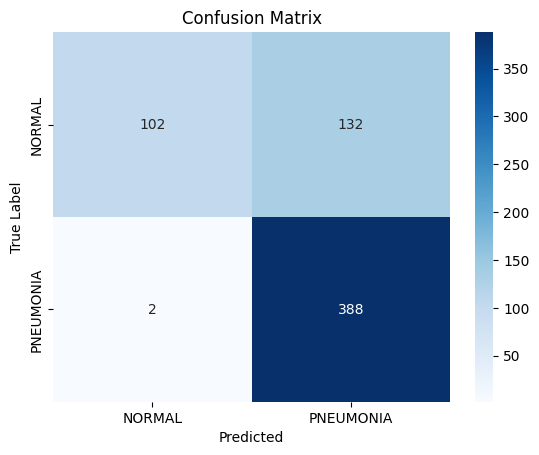

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
print("Confusion Matrix:")
cm = confusion_matrix(yt_t.cpu().numpy(), test_pred.argmax(dim=1).cpu().numpy())
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Now we validate for a pneumonia and a normal diagnosis

In [9]:
torch.save(model.state_dict(), "resnet50_pneumonia_model.pth")
model.load_state_dict(torch.load("resnet50_pneumonia_model.pth"))

C:\Users\PRATYUSH\AppData\Local\Temp\ipykernel_25864\1467698682.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("resnet50_pneumonia_mode

<All keys matched successfully>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0496471].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.08956].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0536385].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.08956].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0656123].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0656123].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0177169].
Clipping input data to the valid range

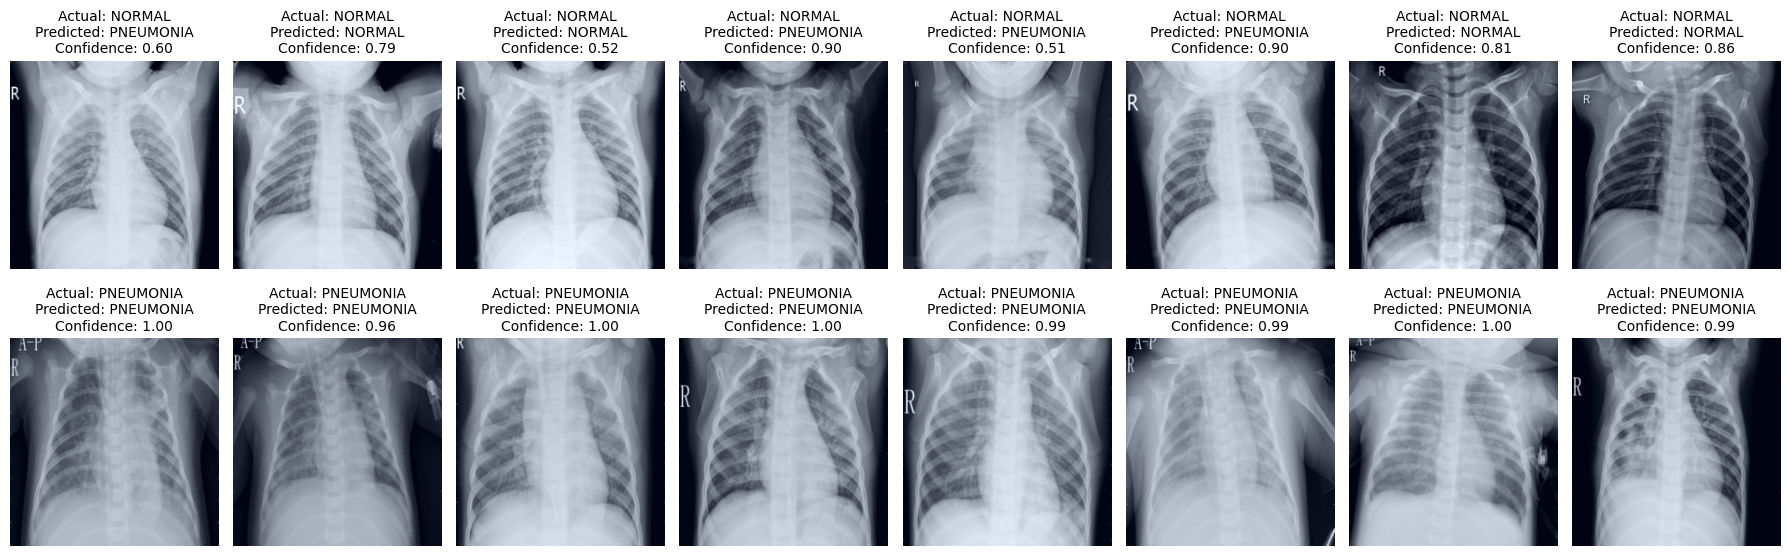

In [10]:
images, labels = next(iter(vali_loader))
images = images.to(device)
labels = labels.to(device)
model = model.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)
    confidences, preds = torch.softmax(outputs, 1).max(1)
classes = val_data.classes

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()
confidences = confidences.cpu()

fig, axes = plt.subplots(2, len(images)//2, figsize=(18,6))
axes = axes.flatten()

for i in range(len(images)):

    img = images[i]
    img = img.permute(1,2,0)
    img = img * 0.229 + 0.485

    axes[i].imshow(img, cmap="gray")

    true_label = classes[labels[i]]
    pred_label = classes[preds[i]]

    axes[i].set_title(f"Actual: {true_label}\nPredicted: {pred_label}\nConfidence: {confidences[i]:.2f}", fontsize=10)
    axes[i].axis("off")

plt.tight_layout()
plt.show()